# YOLOv8 (Refined Model): Training Pipeline and Experiment

## Overview: This notebook shows the development of YOLOv8 for fracture localization on the FracAtlas dataset. This includes data preparation & training and results visualization.


# Step 1: Pre-processing

In [1]:
%matplotlib inline
import os
import cv2
import pandas as pd
from ultralytics import YOLO
import shutil
from pathlib import Path
import random
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg


## Apply oversampling to .csv file
The built-in train function in ultranalytics does not support oversampling for under-represented classes. So, we need to work around that by duplicating the fracture images (from 'FracAtlas/Utilities/Fracture Split/train.csv') and combining them with non-fracture images (from 'FracAtlas/Utilities/Fracture Split/nf_train.csv') such that an instance of fracture images can appear multiple times in the new combined .csv file.

In [2]:
# Create a new train .csv file and apply oversampling

# Load the CSVs
fracture_df = pd.read_csv('FracAtlas/Utilities/Fracture Split/train.csv')        # fracture images only
nonfracture_df = pd.read_csv('FracAtlas/Utilities/Fracture Split/nf_train.csv')  # non-fracture images only

# Oversample fracture images (4x duplication)
oversampled_fractures = pd.concat([fracture_df] * 4, ignore_index=True)

# Combine and shuffle
combined_df = pd.concat([oversampled_fractures, nonfracture_df], ignore_index=True)
combined_df = combined_df.sample(frac=1, random_state=42)  # shuffle rows


# Save the result
combined_df[['image_id']].to_csv('FracAtlas/Utilities/Fracture Split/train_combined.csv', index=False)

print(f"Combined dataset saved with {len(combined_df)} entries.")

Combined dataset saved with 4991 entries.


## Re-arange the dataset folder

The YOLOv8 built-in train function works with a specific input folder structure. We need to rearrange the dataset into a new folder called 'FracAtlas-YOLO' following that structure and create a dataset.yaml file to tell the model wehere to find the data.

In [3]:
split_csv_path = os.path.join('.', 'FracAtlas', 'Utilities', 'Fracture Split')
test_csv = os.path.join(split_csv_path, 'test_combined.csv')
val_csv = os.path.join(split_csv_path, 'valid_combined.csv')
train_csv = os.path.join(split_csv_path, 'train_combined.csv')
image_dir = os.path.join('.', 'FracAtlas', 'images', 'CLAHE')
label_dir = os.path.join('.', 'FracAtlas', 'Annotations', 'YOLO')
output_dir = os.path.join('.', 'FracAtlas-YOLO')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

splits = {
    'train': train_df['image_id'].tolist(),
    'val': val_df['image_id'].tolist(),
    'test': test_df['image_id'].tolist()
}

for split, image_ids in splits.items():
    img_dst = Path(output_dir) / 'images' / split
    lbl_dst = Path(output_dir) / 'labels' / split
    img_dst.mkdir(parents=True, exist_ok=True)
    lbl_dst.mkdir(parents=True, exist_ok=True)

    for img_id in image_ids:
        # Ensure extensions are consistent
        img_name = img_id
        lbl_name = img_name.replace('.jpg', '.txt')

        # Source paths
        src_img = Path(image_dir) / img_name
        src_lbl = Path(label_dir) / lbl_name

        # Destination paths
        dst_img = img_dst / img_name
        dst_lbl = lbl_dst / lbl_name

        # Copy image
        if src_img.exists():
            shutil.copy2(src_img, dst_img)
      

        # Copy label (if it exists)
        if src_lbl.exists():
            shutil.copy2(src_lbl, dst_lbl)
        else:
            # Empty label file if none exists
            dst_lbl.write_text('')

# Write dataset.yaml
yaml_path = Path(output_dir) / 'dataset.yaml'
yaml_content = f"""path: {Path(output_dir).resolve()}
train: images/train
val: images/val
test: images/test

names:
    0: fracture
"""
yaml_path.write_text(yaml_content)
print(f"[Done] Dataset prepared and dataset.yaml written to: {yaml_path}")




[Done] Dataset prepared and dataset.yaml written to: FracAtlas-YOLO/dataset.yaml


# Step 2: Define train, evaluate and visualization function


In [2]:
def train_yolov8(hyperparams):
    """
    Initialize a YOLOv8 model and train it
    - 'hyperparams': hyperparameters to train the model with
    """
    model = YOLO(hyperparams['model'])

    model.train(
        data=hyperparams['data'],
        imgsz=hyperparams['imgsz'],
        epochs=hyperparams['epochs'],
        batch=hyperparams['batch'],
        name=hyperparams['name'],
        project=hyperparams['project'],
        optimizer=hyperparams['optimizer'],
        lr0=hyperparams['lr0'],
        momentum=hyperparams['momentum'],
        weight_decay=hyperparams['weight_decay'],
        cos_lr=hyperparams['cos_lr'],
        augment=hyperparams['augment'],
        hsv_h=hyperparams['hsv_h'],
        hsv_s=hyperparams['hsv_s'],
        hsv_v=hyperparams['hsv_v'],
        degrees=hyperparams['degrees'],
        translate=hyperparams['translate'],
        scale=hyperparams['scale'],
        shear=hyperparams['shear'],
        flipud=hyperparams['flipud'],
        fliplr=hyperparams['fliplr'],
        mosaic=hyperparams['mosaic'],
        mixup=hyperparams['mixup'],
        device=hyperparams['device'],
        pretrained=hyperparams['pretrained'],
        workers=hyperparams['workers'],
        patience=hyperparams['patience'],
    )

    return model

In [13]:
def evaluate(model, split='test'):
    """
    Evaluates a YOLOv8 model on the validation or test set.
    - `model`: YOLO model object or a string path to weights.
    - `split`:decide which data split to use, can be  'val' or 'test', 
    """
    # Allow passing in either a path or model object
    if isinstance(model, str):
        model = YOLO(model)

    # Run evaluation
    results = model.val(split=split, conf=0.5)
    print(f"mAP@0.5: {results.box.map50}\n")
    print(f"mAP@0.5:0.95: {results.box.map}\n")
    print(f"Precision: {results.box.p}\n")
    print(f"Recall: {results.box.r}\n")
    print(f"F1 Score: {results.box.f1}\n")
    return results.save_dir


In [4]:

def plot_loss_and_metrics(results_csv_path):
    """
    Plot the training and validation loss and metrics
    - 'results_csv_path': path to the results.csv file generted during the training step
    
    """
    df = pd.read_csv(results_csv_path)

    fig, axs = plt.subplots(3, 1, figsize=(12, 10))

    # --- Plot losses ---
    axs[0].plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
    axs[0].plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
    if "train/cls_loss" in df:
        axs[0].plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")

 
    axs[0].set_title("Train Losses")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].legend()
    axs[0].grid(True)

    # Plot val loss
    if "val/box_loss" in df:
        axs[1].plot(df["epoch"], df["val/box_loss"], label="Val Box Loss")
    if "val/dfl_loss" in df:
        axs[1].plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss")
    if "val/cls_loss" in df:
        axs[1].plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss")

    
    axs[1].set_title("Val Losses")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Loss")
    axs[1].legend()
    axs[1].grid(True)


    # --- Plot metrics ---
    axs[2].plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
    axs[2].plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
    axs[2].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
    axs[2].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")

    axs[2].set_title("Validation Metrics")
    axs[2].set_xlabel("Epoch")
    axs[2].set_ylabel("Value")
    axs[2].legend()
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()



In [5]:
def display_eval_curves(run_dir):
    """
    Display confusion matrix, F1 curve and PR curve from YOLOv8 evaluation results.

    Args:
        run_dir (str): Path to the evaluation run folder 
    """
    plot_files = {
        'Confusion Matrix': 'confusion_matrix.png',
        'F1 Curve': 'F1_curve.png',
        'PR Curve': 'PR_curve.png',
    }

    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    axes = axes.ravel()

    for idx, (title, filename) in enumerate(plot_files.items()):
        img_path = os.path.join(run_dir, filename)
        if os.path.exists(img_path):
            image = mpimg.imread(img_path)
            axes[idx].imshow(image)
            axes[idx].set_title(title)
            axes[idx].axis('off')
        else:
            print(img_path)
            axes[idx].text(0.5, 0.5, f'{filename} not found', 
                           ha='center', va='center', fontsize=12, color='red')
            axes[idx].set_title(title)
            axes[idx].axis('off')

    plt.tight_layout()
    plt.show()
    
    

In [6]:
def visualize_prediction_vs_ground_truth_from_testset(
    model,
    conf_thresh=0.25
):
    """
    Automatically selects one fractured test image, runs prediction,
    and visualizes predicted vs. ground truth bounding boxes.

    Parameters:
    - model: Trained YOLOv8 model 
    - conf_thresh: Minimum confidence threshold to draw predicted boxes
    """
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    
    test_images_dir = 'FracAtlas-YOLO/images/test'
    test_labels_dir = 'FracAtlas-YOLO/labels/test'
    
    test_images = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(test_images)

    for img_name in test_images:
        image_path = os.path.join(test_images_dir, img_name)
        annotation_path = os.path.join(test_labels_dir, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))

        # Load image
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]

        # Run YOLOv8 prediction
        results = model(image_path, verbose=False, stream=False)[0]
        pred_boxes = results.boxes.xyxy.cpu()
        scores = results.boxes.conf.cpu()

        # Filter by confidence
        selected_indices = [i for i, s in enumerate(scores) if s >= conf_thresh]
        if not selected_indices:
            continue  # No detections, pick another image

        pred_boxes = pred_boxes[selected_indices]
        scores = scores[selected_indices]

        # Load ground truth
        gt_boxes = []
        if os.path.exists(annotation_path) and os.path.getsize(annotation_path) > 0:
            with open(annotation_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, x_center, y_center, box_w, box_h = map(float, parts)
                        x1 = (x_center - box_w / 2) * w
                        y1 = (y_center - box_h / 2) * h
                        x2 = (x_center + box_w / 2) * w
                        y2 = (y_center + box_h / 2) * h
                        gt_boxes.append([x1, y1, x2, y2])

        # Draw
        fig, ax = plt.subplots(1, figsize=(10, 10))
        ax.imshow(image_rgb)

        for box in gt_boxes:
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     linewidth=2, edgecolor='green', facecolor='none', label='GT')
            ax.add_patch(rect)

        for box in pred_boxes:
            x1, y1, x2, y2 = box.tolist()
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     linewidth=2, edgecolor='red', facecolor='none', label='Pred')
            ax.add_patch(rect)

        ax.set_title('Green: Ground Truth, Red: Prediction')
        plt.axis('off')
        plt.show()
        # plt.savefig(save_path)
        plt.close()
        return

# Step 3: Training
## Baseline model

In [89]:
HYPERPARAMS = {
    'model': 'yolov8m.pt',                    # or yolov8s.pt, yolov8m.pt, etc.
    'data': 'FracAtlas-YOLO/dataset.yaml',         # path to your YAML file
    'imgsz': 640,                             # image size
    'epochs': 50,
    'batch': 16,
    'name': 'yolov8m-baseline',              # run name
    'project': 'fracatlas_runs',               # output folder

    # Optimizer and scheduler
    'optimizer': 'SGD',                       
    'lr0': 1e-3,                              # initial learning rate
    'momentum': 0.937,
    'weight_decay': 5e-4,
    'cos_lr': True,                           # cosine learning rate scheduler

    # Data augmentations
    'augment': True,
    'hsv_h': 0.015,                           # hue augmentation
    'hsv_s': 0.7,                             # saturation
    'hsv_v': 0.4,                             # value
    'degrees': 0.0,
    'translate': 0.1,
    'scale': 0.5,
    'shear': 0.0,
    'flipud': 0.0,
    'fliplr': 0.5,
    'mosaic': 1.0,
    'mixup': 0.1,

    # Other settings
    'device': 0,                              # GPU index
    'pretrained': True,
    'workers': 8,                             # DataLoader workers
    'patience': 5                            # Early stopping
}

model = train_yolov8(HYPERPARAMS)



Ultralytics 8.3.111 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48546MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=FracAtlas-YOLO/dataset.yaml, epochs=50, time=None, patience=5, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=fracatlas_runs, name=yolov8m-baseline, exist_ok=False, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_con

train: Scanning /home/public/ntran1/fracatlas_project/FracAtlas-YOLO/labels/train.cache... 3269 images, 2695 backgrounds, 0 corrupt: 100%|██████████| 3269/3269 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 821.8±391.4 MB/s, size: 29.6 KB)


val: Scanning /home/public/ntran1/fracatlas_project/FracAtlas-YOLO/labels/val.cache... 83 images, 385 backgrounds, 0 corrupt: 100%|██████████| 467/467 [00:00<?, ?it/s]


...

      33/50      7.86G      1.402      1.022      1.114          1        640: 100%|██████████| 205/205 [00:51<00:00,  3.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:02<00:00,  5.69it/s]

                   all        467         91      0.576      0.484      0.488      0.239
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 28, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



33 epochs completed in 0.502 hours.
Optimizer stripped from fracatlas_runs/yolov8m-baseline/weights/last.pt, 52.0MB
Optimizer stripped from fracatlas_runs/yolov8m-baseline/weights/best.pt, 52.0MB

Validating fracatlas_runs/yolov8m-baseline/weights/best.pt...
Ultralytics 8.3.111 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48546MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:05<00:00,  2.74it/s]


                   all        467         91      0.672      0.494      0.484       0.24
Speed: 1.1ms preprocess, 8.1ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to fracatlas_runs/yolov8m-baseline


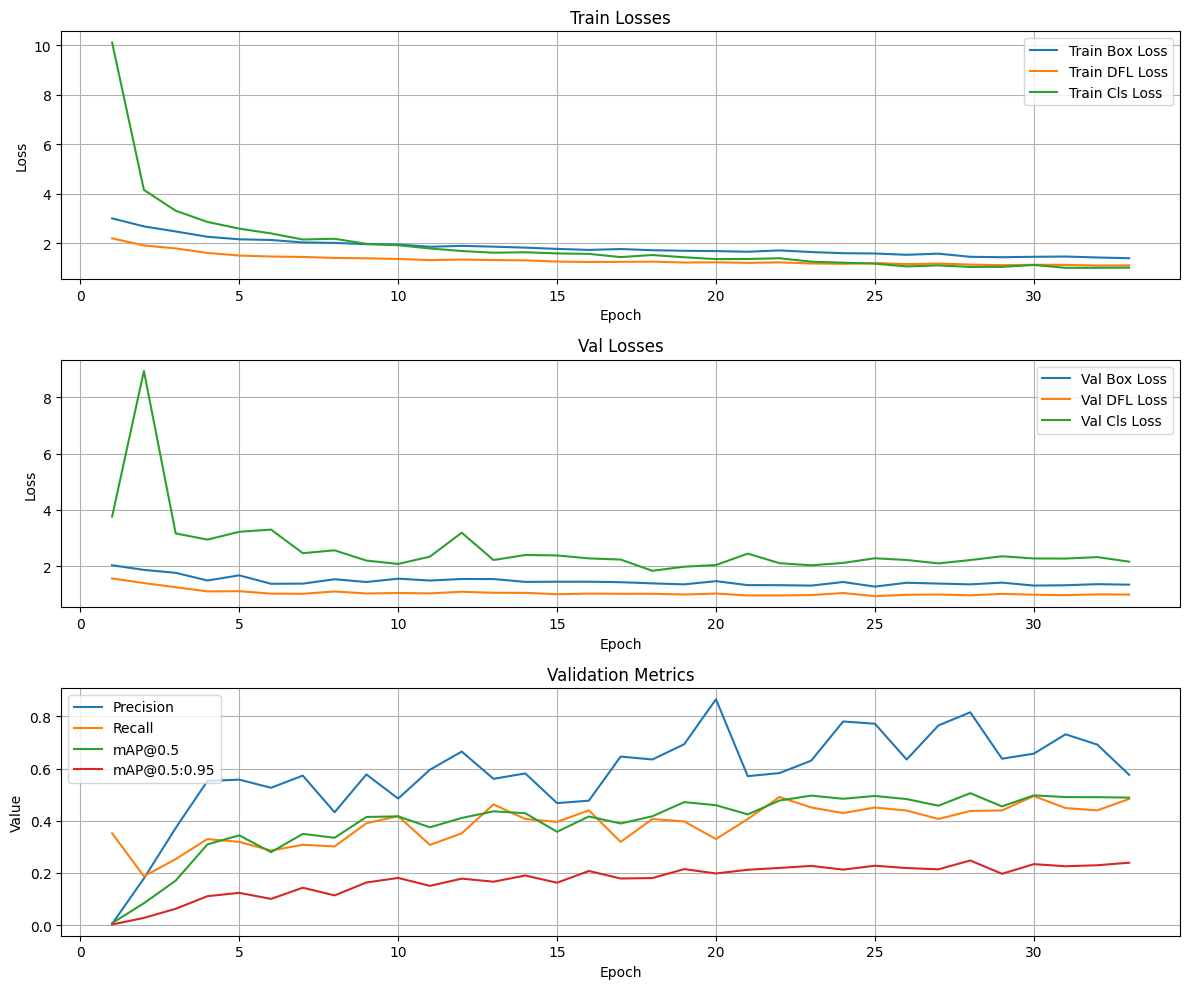

In [92]:
plot_loss_and_metrics('fracatlas_runs/yolov8m-baseline/results.csv')

In [29]:
model = YOLO('fracatlas_runs/yolov8m-baseline/weights/best.pt')
baseline_eval_dir = evaluate(model)

Ultralytics 8.3.111 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48546MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1344.4±398.8 MB/s, size: 30.4 KB)


val: Scanning /home/public/ntran1/fracatlas_project/FracAtlas-YOLO/labels/test.cache... 62 images, 286 backgrounds, 0 corrupt: 100%|██████████| 347/347 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 22/22 [00:03<00:00,  7.25it/s]


                   all        347         67      0.844      0.403      0.596      0.325
Speed: 2.3ms preprocess, 3.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to runs/detect/val5
mAP@0.5: 0.59577578125

mAP@0.5:0.95: 0.3252401299370035

Precision: [    0.84375]

Recall: [    0.40299]

F1 Score: [    0.54545]



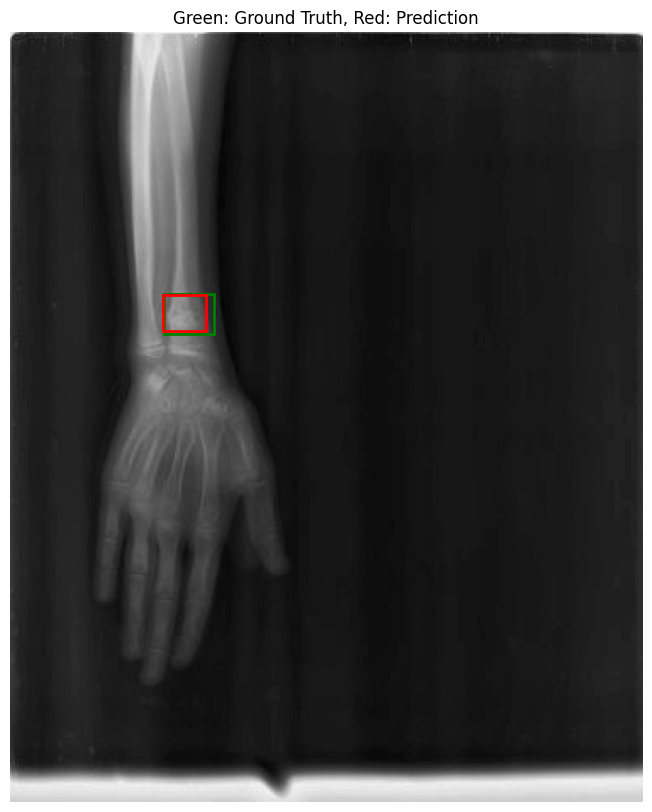

In [30]:
visualize_prediction_vs_ground_truth_from_testset(model)

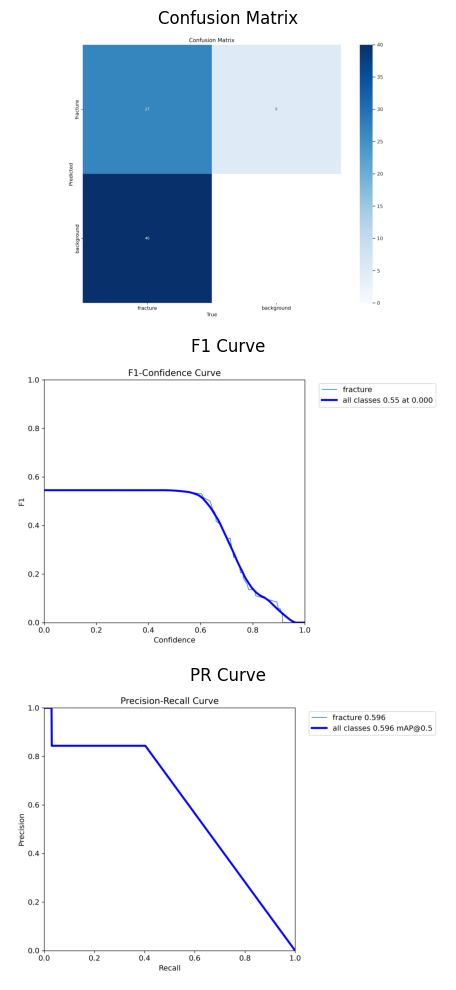

In [31]:
display_eval_curves(baseline_eval_dir)

## Experiment 1: 
In this experiment, the learning rate is reduced from 1e-3 to 1e-4. Other parameters are kept the same

In [99]:
HYPERPARAMS_REFINED_1 = {
    'model': 'yolov8m.pt',                    
    'data': 'FracAtlas-YOLO/dataset.yaml',         # path to  YAML file
    'imgsz': 640,                             # image size
    'epochs': 50,
    'batch': 16,
    'name': 'yolov8m-lr_adjustment',              # run name
    'project': 'fracatlas_runs',               # output folder

    # Optimizer and scheduler
    'optimizer': 'SGD',                       
    'lr0': 1e-4,                              # initial learning rate
    'momentum': 0.937,
    'weight_decay': 1e-4,
    'cos_lr': True,                           # cosine learning rate scheduler

    # Data augmentations
    'augment': True,
    'hsv_h': 0.015,                           # hue augmentation
    'hsv_s': 0.7,                             # saturation
    'hsv_v': 0.4,                             # value
    'degrees': 0.0,
    'translate': 0.1,
    'scale': 0.5,
    'shear': 0.0,
    'flipud': 0.0,
    'fliplr': 0.5,
    'mosaic': 1.0,
    'mixup': 0.1,

    # Other settings
    'device': 0,                              # GPU index
    'pretrained': True,
    'workers': 8,                             # DataLoader workers
    'patience': 10                            # Early stopping
}

model_refined_1 = train_yolov8(HYPERPARAMS_REFINED_1)


Ultralytics 8.3.111 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48546MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=FracAtlas-YOLO/dataset.yaml, epochs=50, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=fracatlas_runs, name=yolov8m-lr_adjustment2, exist_ok=False, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, s

train: Scanning /home/public/ntran1/fracatlas_project/FracAtlas-YOLO/labels/train.cache... 3269 images, 2695 backgrounds, 0 corrupt: 100%|██████████| 3269/3269 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 457.5±213.5 MB/s, size: 29.6 KB)


val: Scanning /home/public/ntran1/fracatlas_project/FracAtlas-YOLO/labels/val.cache... 83 images, 385 backgrounds, 0 corrupt: 100%|██████████| 467/467 [00:00<?, ?it/s]


...

      36/50      7.84G       1.85      1.738      1.366          2        640: 100%|██████████| 205/205 [00:55<00:00,  3.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:02<00:00,  5.30it/s]

                   all        467         91      0.516      0.418       0.41        0.2
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 26, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



36 epochs completed in 0.572 hours.
Optimizer stripped from fracatlas_runs/yolov8m-lr_adjustment2/weights/last.pt, 52.0MB
Optimizer stripped from fracatlas_runs/yolov8m-lr_adjustment2/weights/best.pt, 52.0MB

Validating fracatlas_runs/yolov8m-lr_adjustment2/weights/best.pt...
Ultralytics 8.3.111 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48546MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:05<00:00,  2.85it/s]


                   all        467         91      0.627      0.396      0.422       0.21
Speed: 0.1ms preprocess, 8.6ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to fracatlas_runs/yolov8m-lr_adjustment2


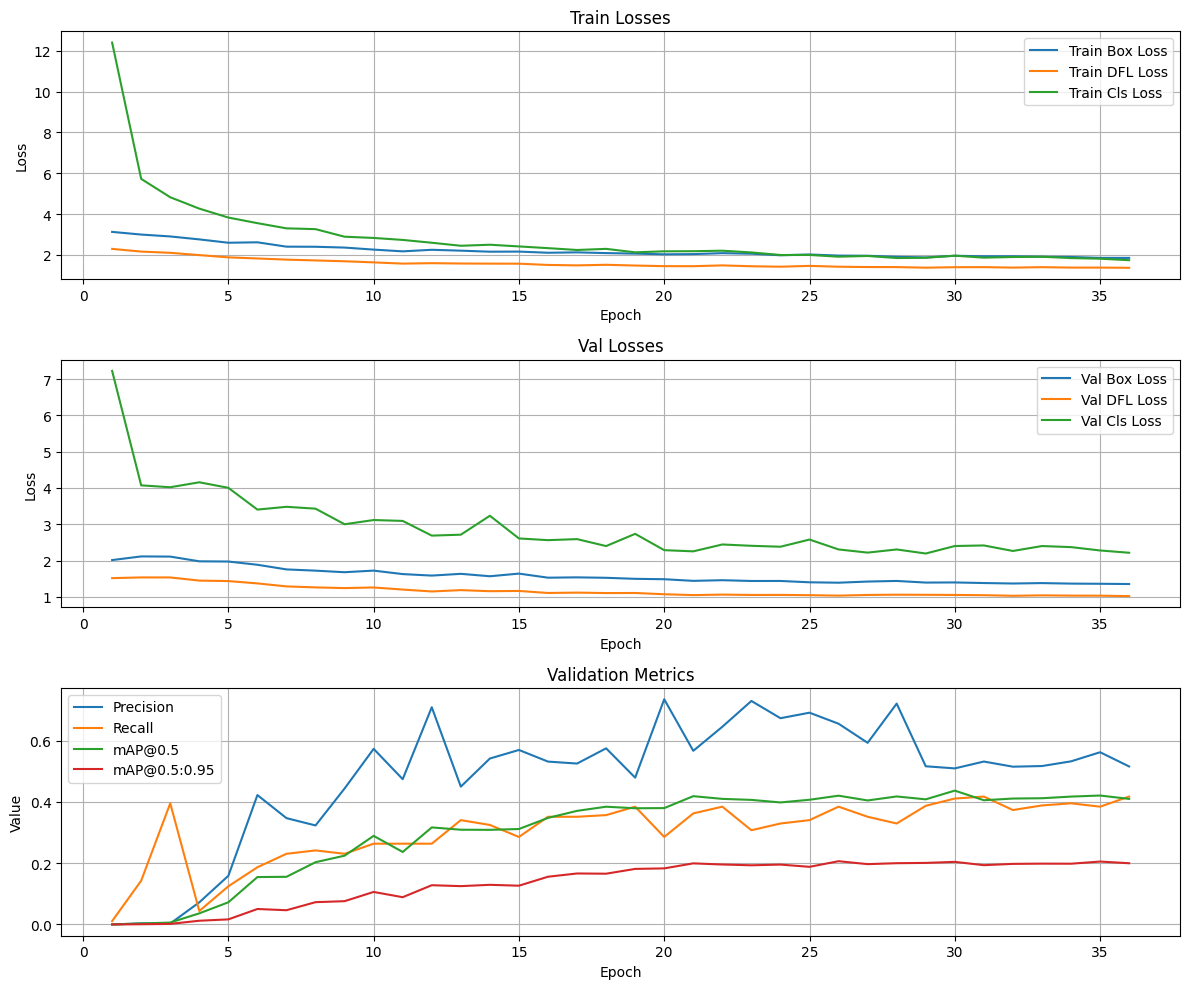

In [100]:
plot_loss_and_metrics('fracatlas_runs/yolov8m-lr_adjustment2/results.csv')

In [26]:
model_refined_1 = YOLO('fracatlas_runs/yolov8m-lr_adjustment2/weights/best.pt')
refined_1_eval_dir = evaluate(model_refined_1)

Ultralytics 8.3.111 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48546MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1288.6±736.4 MB/s, size: 303.5 KB)


val: Scanning /home/public/ntran1/fracatlas_project/FracAtlas-YOLO/labels/test.cache... 62 images, 286 backgrounds, 0 corrupt: 100%|██████████| 347/347 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 22/22 [00:01<00:00, 11.52it/s]


                   all        347         67      0.733      0.164      0.434      0.251
Speed: 2.1ms preprocess, 2.4ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to runs/detect/val4
mAP@0.5: 0.433855

mAP@0.5:0.95: 0.25116066685478267

Precision: [    0.73333]

Recall: [    0.16418]

F1 Score: [    0.26829]



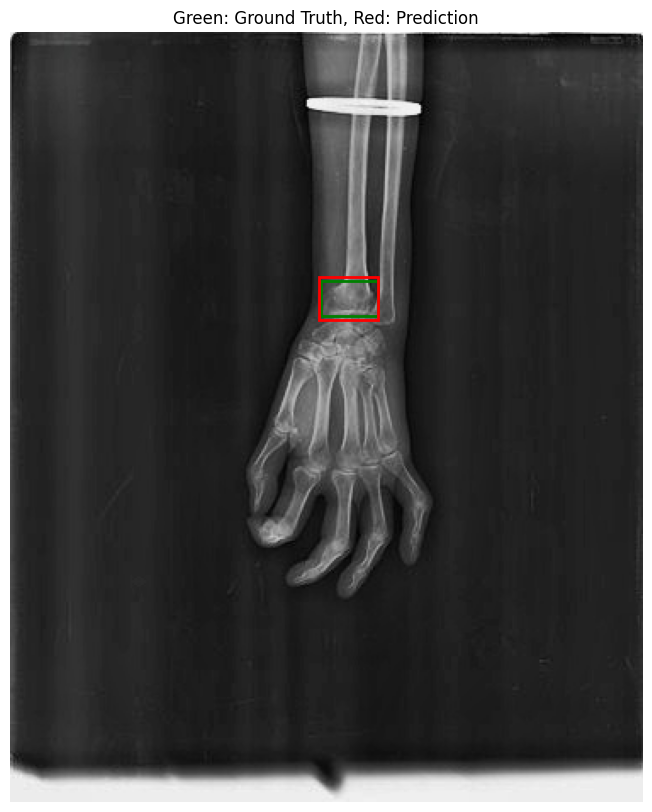

In [27]:
visualize_prediction_vs_ground_truth_from_testset(model_refined_1)

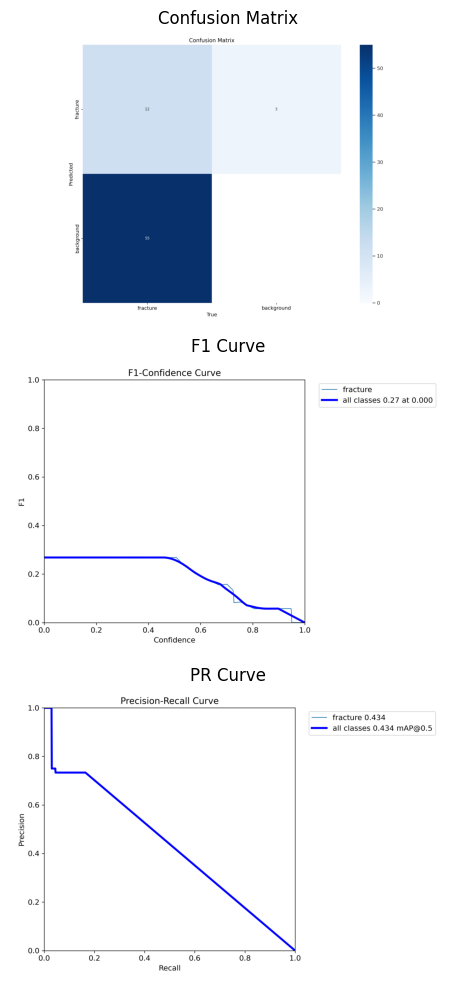

In [28]:
display_eval_curves(refined_1_eval_dir)

# Experiment 2: 
In this experiment, the optimizer is changed from SGD to Adam. Other parameters are kept the same as baseline.

In [104]:
HYPERPARAMS_REFINED_2 = {
    'model': 'yolov8m.pt',                    
    'data': 'FracAtlas-YOLO/dataset.yaml',         # path to  YAML file
    'imgsz': 640,                             # image size
    'epochs': 50,
    'batch': 16,
    'name': 'yolov8m-Adam',              # run name
    'project': 'fracatlas_runs',               # output folder

    # Optimizer and scheduler
    'optimizer': 'Adam',                       
    'lr0': 1e-3,                              # initial learning rate
    'momentum': 0.937,
    'weight_decay': 5e-4,
    'cos_lr': True,                           # cosine learning rate scheduler

    # Data augmentations
    'augment': True,
    'hsv_h': 0.015,                           # hue augmentation
    'hsv_s': 0.7,                             # saturation
    'hsv_v': 0.4,                             # value
    'degrees': 0.0,
    'translate': 0.1,
    'scale': 0.5,
    'shear': 0.0,
    'flipud': 0.0,
    'fliplr': 0.5,
    'mosaic': 1.0,
    'mixup': 0.1,

    # Other settings
    'device': 0,                              # GPU index
    'pretrained': True,
    'workers': 8,                             # DataLoader workers
    'patience': 10                            # Early stopping
}

model_refined_2 = train_yolov8(HYPERPARAMS_REFINED_2)


Ultralytics 8.3.111 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48546MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=FracAtlas-YOLO/dataset.yaml, epochs=50, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=fracatlas_runs, name=yolov8m-Adam, exist_ok=False, pretrained=True, optimizer=Adam, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=

train: Scanning /home/public/ntran1/fracatlas_project/FracAtlas-YOLO/labels/train.cache... 3269 images, 2695 backgrounds, 0 corrupt: 100%|██████████| 3269/3269 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1269.0±680.1 MB/s, size: 29.6 KB)


val: Scanning /home/public/ntran1/fracatlas_project/FracAtlas-YOLO/labels/val.cache... 83 images, 385 backgrounds, 0 corrupt: 100%|██████████| 467/467 [00:00<?, ?it/s]


...

      50/50       8.4G      1.654      1.492      1.379          4        640: 100%|██████████| 205/205 [00:51<00:00,  3.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:01<00:00,  8.91it/s]

                   all        467         91      0.637      0.429      0.428      0.189



50 epochs completed in 0.792 hours.
Optimizer stripped from fracatlas_runs/yolov8m-Adam/weights/last.pt, 52.0MB
Optimizer stripped from fracatlas_runs/yolov8m-Adam/weights/best.pt, 52.0MB

Validating fracatlas_runs/yolov8m-Adam/weights/best.pt...
Ultralytics 8.3.111 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48546MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:05<00:00,  2.83it/s]


                   all        467         91      0.616       0.44      0.456       0.22
Speed: 0.1ms preprocess, 8.7ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to fracatlas_runs/yolov8m-Adam


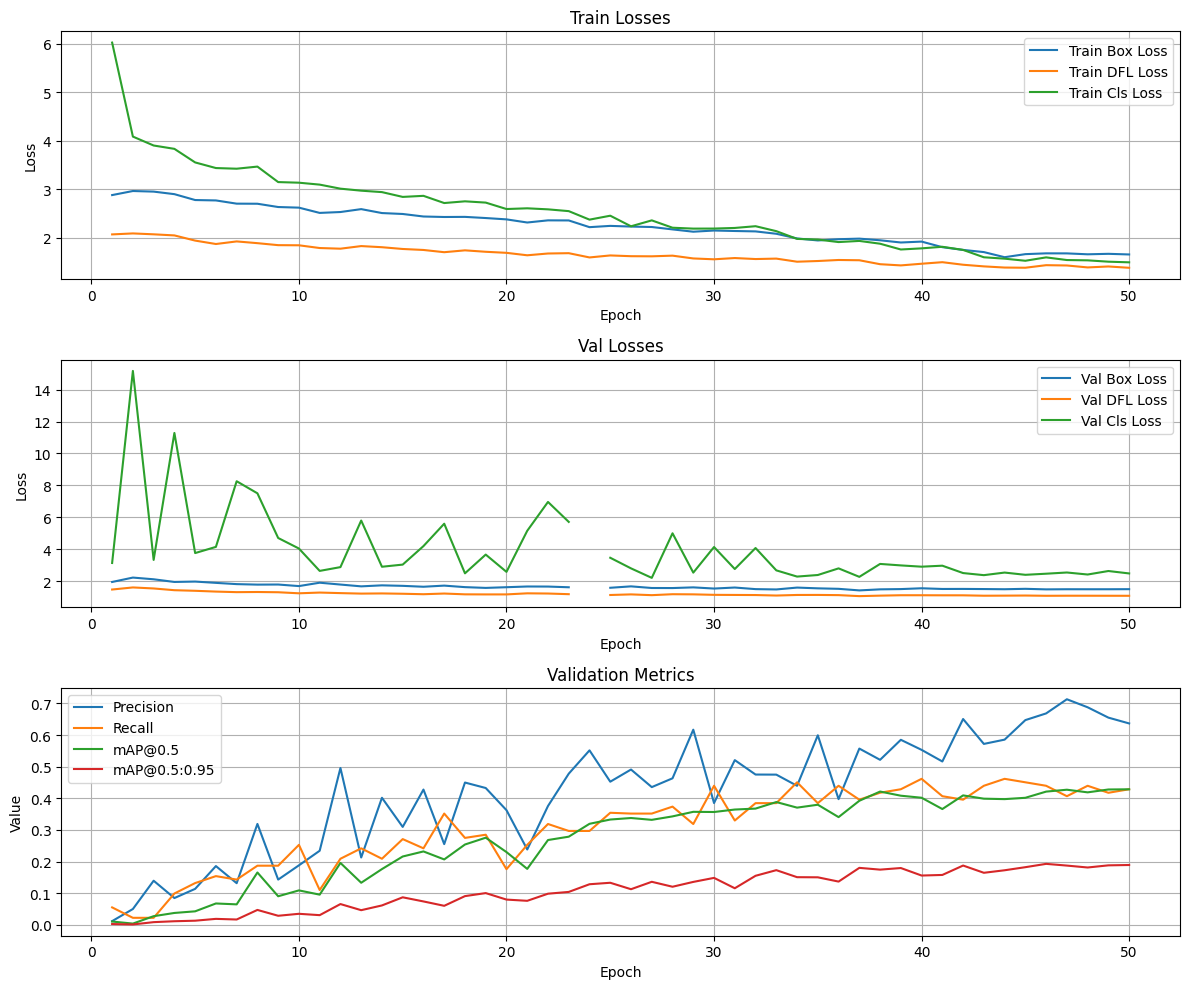

In [105]:
plot_loss_and_metrics('fracatlas_runs/yolov8m-Adam/results.csv')

In [21]:
model_refined_2 = YOLO('fracatlas_runs/yolov8m-Adam/weights/best.pt')
refined_2_eval_dir = evaluate(model_refined_2)

Ultralytics 8.3.111 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48546MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1520.7±643.1 MB/s, size: 244.9 KB)


val: Scanning /home/public/ntran1/fracatlas_project/FracAtlas-YOLO/labels/test.cache... 62 images, 286 backgrounds, 0 corrupt: 100%|██████████| 347/347 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 22/22 [00:02<00:00,  9.58it/s]


                   all        347         67       0.75      0.179      0.473      0.245
Speed: 2.8ms preprocess, 2.8ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to runs/detect/val3
mAP@0.5: 0.47310276223776226

mAP@0.5:0.95: 0.2454272249521312

Precision: [       0.75]

Recall: [     0.1791]

F1 Score: [    0.28916]



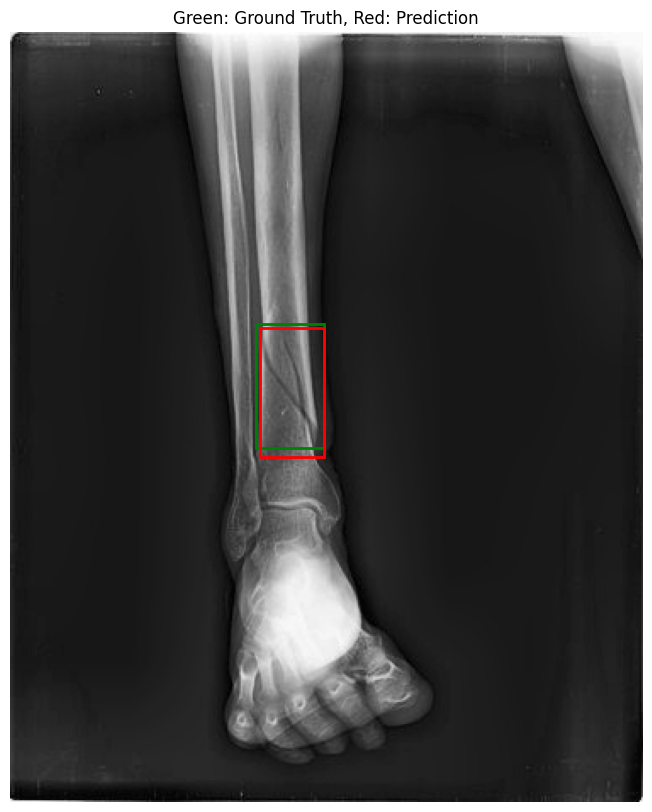

In [24]:
visualize_prediction_vs_ground_truth_from_testset(model_refined_2)

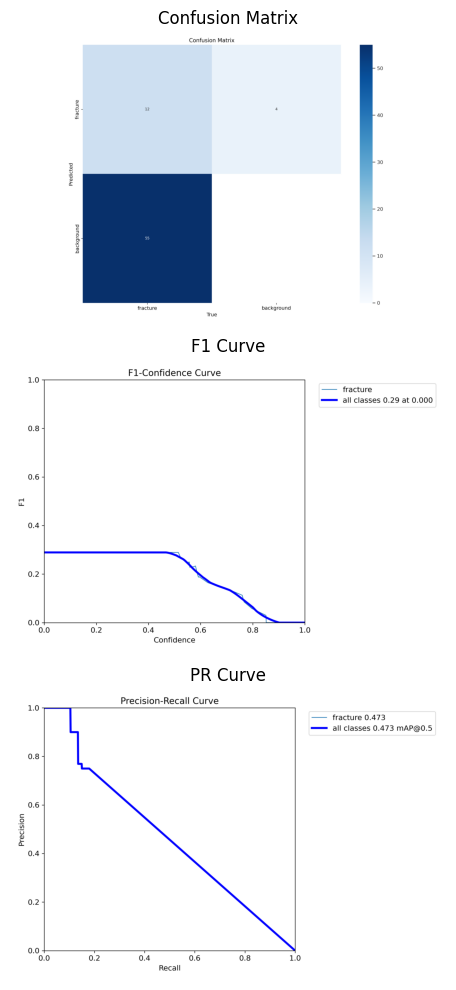

In [25]:
display_eval_curves(refined_2_eval_dir)

# Experiment 3:
Since early stopping is not triggered in experiment 2, I believe the model can be train for even longer. In this experiment, the model is the same as the one in experiment 2 (optimizer = 'Adam'), but the number of epochs is increased from 50 to 100.

In [7]:
HYPERPARAMS_REFINED_3 = {
    'model': 'yolov8m.pt',                    
    'data': 'FracAtlas-YOLO/dataset.yaml',         # path to  YAML file
    'imgsz': 640,                             # image size
    'epochs': 100,
    'batch': 16,
    'name': 'yolov8m-Adam',              # run name
    'project': 'fracatlas_runs',               # output folder

    # Optimizer and scheduler
    'optimizer': 'Adam',                       
    'lr0': 1e-3,                              # initial learning rate
    'momentum': 0.937,
    'weight_decay': 5e-4,
    'cos_lr': True,                           # cosine learning rate scheduler

    # Data augmentations
    'augment': True,
    'hsv_h': 0.015,                           # hue augmentation
    'hsv_s': 0.7,                             # saturation
    'hsv_v': 0.4,                             # value
    'degrees': 0.0,
    'translate': 0.1,
    'scale': 0.5,
    'shear': 0.0,
    'flipud': 0.0,
    'fliplr': 0.5,
    'mosaic': 1.0,
    'mixup': 0.1,

    # Other settings
    'device': 0,                              # GPU index
    'pretrained': True,
    'workers': 8,                             # DataLoader workers
    'patience': 10                            # Early stopping
}

model_refined_3 = train_yolov8(HYPERPARAMS_REFINED_3)

Ultralytics 8.3.111 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48546MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=FracAtlas-YOLO/dataset.yaml, epochs=100, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=fracatlas_runs, name=yolov8m-Adam4, exist_ok=False, pretrained=True, optimizer=Adam, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_con

E0000 00:00:1745158557.060045 3906281 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745158557.064370 3906281 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

train: Scanning /home/public/ntran1/fracatlas_project/FracAtlas-YOLO/labels/train.cache... 3269 images, 2695 backgrounds, 0 corrupt: 100%|██████████| 3269/3269 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 726.2±359.6 MB/s, size: 29.6 KB)


...

     72/100      7.85G      1.603      1.346      1.315          1        640: 100%|██████████| 205/205 [00:49<00:00,  4.15it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:01<00:00, 13.02it/s]

                   all        467         91      0.647      0.422      0.436      0.188
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 62, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



72 epochs completed in 1.029 hours.
Optimizer stripped from fracatlas_runs/yolov8m-Adam4/weights/last.pt, 52.0MB
Optimizer stripped from fracatlas_runs/yolov8m-Adam4/weights/best.pt, 52.0MB

Validating fracatlas_runs/yolov8m-Adam4/weights/best.pt...
Ultralytics 8.3.111 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48546MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:06<00:00,  2.38it/s]


                   all        467         91       0.69      0.484        0.5      0.229
Speed: 0.1ms preprocess, 10.8ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to fracatlas_runs/yolov8m-Adam4


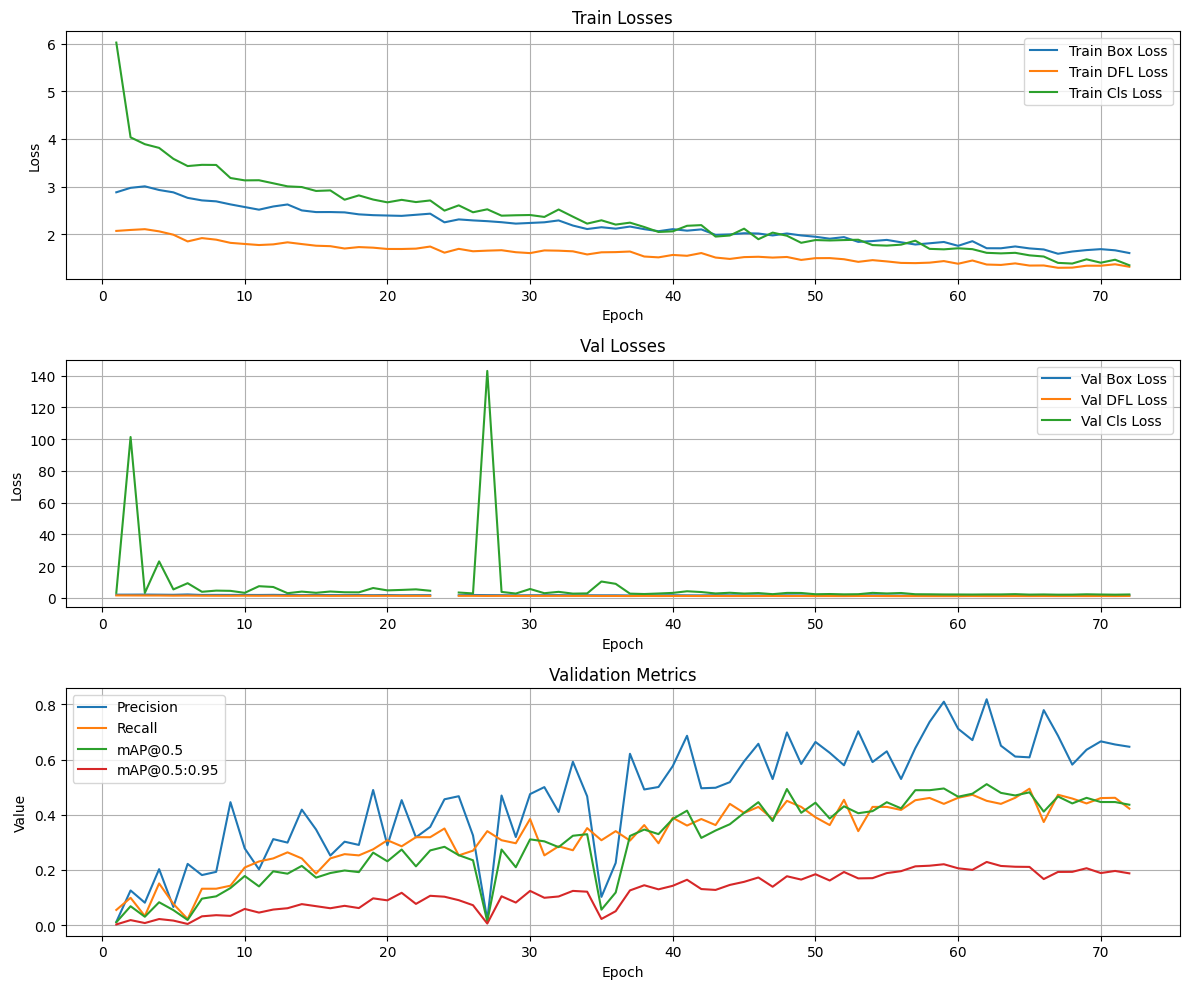

In [8]:
plot_loss_and_metrics('fracatlas_runs/yolov8m-Adam4/results.csv')

In [18]:
model_refined_3 = YOLO('fracatlas_runs/yolov8m-Adam4/weights/best.pt')
refined_3_eval_dir = evaluate(model_refined_3)

Ultralytics 8.3.111 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48546MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1317.5±432.5 MB/s, size: 26.2 KB)


val: Scanning /home/public/ntran1/fracatlas_project/FracAtlas-YOLO/labels/test.cache... 62 images, 286 backgrounds, 0 corrupt: 100%|██████████| 347/347 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 22/22 [00:03<00:00,  6.84it/s]


                   all        347         67       0.75      0.269      0.504      0.223
Speed: 1.2ms preprocess, 4.1ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/detect/val2
mAP@0.5: 0.5035920377241806

mAP@0.5:0.95: 0.22251668741164488

Precision: [       0.75]

Recall: [    0.26866]

F1 Score: [     0.3956]



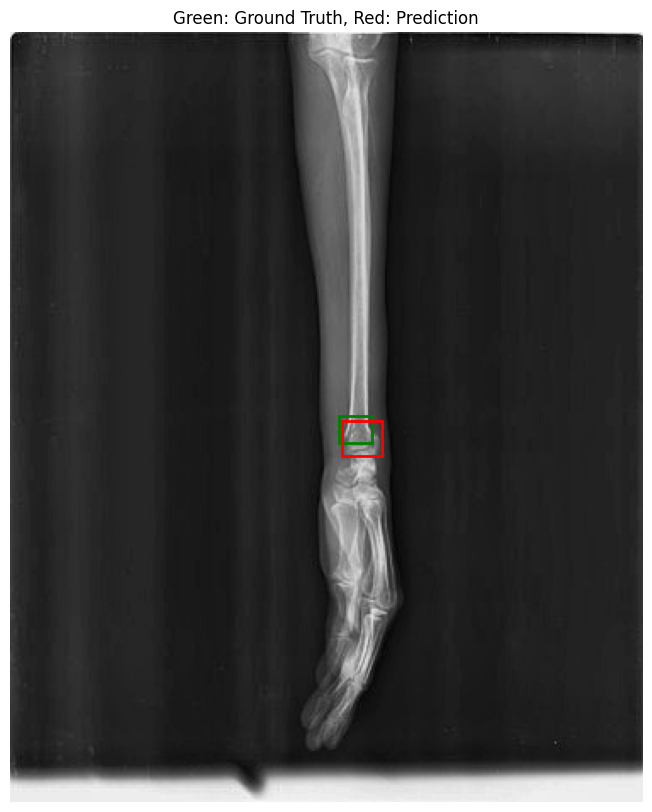

In [19]:
visualize_prediction_vs_ground_truth_from_testset(model_refined_3)

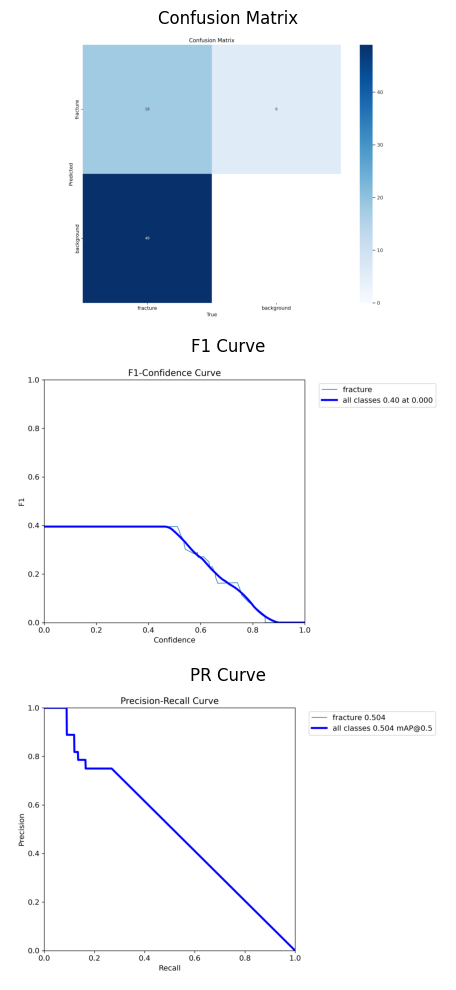

In [20]:
display_eval_curves(refined_3_eval_dir)

## Experiment 4: 
This experiment combines all the changes made in previous model variants including changing the optimizer to Adam, doubling the number of epochs and reducing the learning rate from 1e-3 to 1e-4

In [12]:
HYPERPARAMS_REFINED_4 = {
    'model': 'yolov8m.pt',                    
    'data': 'FracAtlas-YOLO/dataset.yaml',         # path to  YAML file
    'imgsz': 640,                             # image size
    'epochs': 100,
    'batch': 16,
    'name': 'yolov8m-Adam',              # run name
    'project': 'fracatlas_runs',               # output folder

    # Optimizer and scheduler
    'optimizer': 'Adam',                       
    'lr0': 3e-4,                              # initial learning rate
    'momentum': 0.937,
    'weight_decay': 5e-4,
    'cos_lr': True,                           # cosine learning rate scheduler

    # Data augmentations
    'augment': True,
    'hsv_h': 0.015,                           # hue augmentation
    'hsv_s': 0.7,                             # saturation
    'hsv_v': 0.4,                             # value
    'degrees': 0.0,
    'translate': 0.1,
    'scale': 0.5,
    'shear': 0.0,
    'flipud': 0.0,
    'fliplr': 0.5,
    'mosaic': 1.0,
    'mixup': 0.1,

    # Other settings
    'device': 0,                              # GPU index
    'pretrained': True,
    'workers': 8,                             # DataLoader workers
    'patience': 10                            # Early stopping
}

model_refined_4 = train_yolov8(HYPERPARAMS_REFINED_4)

Ultralytics 8.3.111 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48546MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=FracAtlas-YOLO/dataset.yaml, epochs=100, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=fracatlas_runs, name=yolov8m-Adam5, exist_ok=False, pretrained=True, optimizer=Adam, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_con

train: Scanning /home/public/ntran1/fracatlas_project/FracAtlas-YOLO/labels/train.cache... 3269 images, 2695 backgrounds, 0 corrupt: 100%|██████████| 3269/3269 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 592.3±222.8 MB/s, size: 29.6 KB)


val: Scanning /home/public/ntran1/fracatlas_project/FracAtlas-YOLO/labels/val.cache... 83 images, 385 backgrounds, 0 corrupt: 100%|██████████| 467/467 [00:00<?, ?it/s]


...

     50/100      7.38G      1.475      1.118      1.252          3        640: 100%|██████████| 205/205 [00:50<00:00,  4.05it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:01<00:00, 12.53it/s]

                   all        467         91      0.815      0.396      0.465      0.218
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 40, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



50 epochs completed in 0.746 hours.
Optimizer stripped from fracatlas_runs/yolov8m-Adam5/weights/last.pt, 52.0MB
Optimizer stripped from fracatlas_runs/yolov8m-Adam5/weights/best.pt, 52.0MB

Validating fracatlas_runs/yolov8m-Adam5/weights/best.pt...
Ultralytics 8.3.111 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48546MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:03<00:00,  4.07it/s]


                   all        467         91      0.721      0.495      0.509       0.25
Speed: 0.1ms preprocess, 4.5ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to fracatlas_runs/yolov8m-Adam5


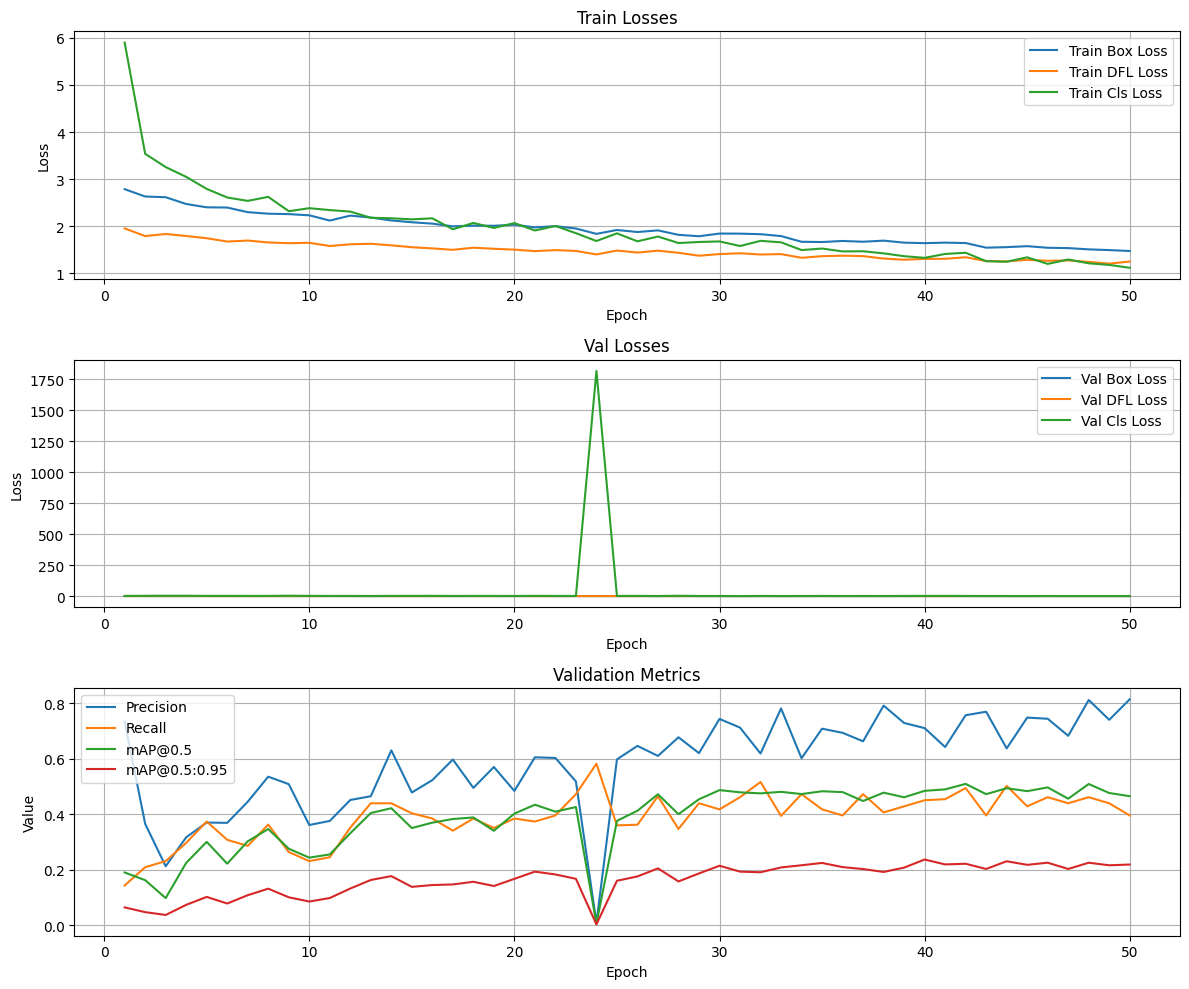

In [14]:
plot_loss_and_metrics('fracatlas_runs/yolov8m-Adam5/results.csv')

In [15]:
model_refined_4 = YOLO('fracatlas_runs/yolov8m-Adam5/weights/best.pt')
refined_4_eval_dir = evaluate(model_refined_4)

Ultralytics 8.3.111 🚀 Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (NVIDIA RTX 6000 Ada Generation, 48546MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1600.8±376.9 MB/s, size: 29.1 KB)


val: Scanning /home/public/ntran1/fracatlas_project/FracAtlas-YOLO/labels/test.cache... 62 images, 286 backgrounds, 0 corrupt: 100%|██████████| 347/347 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 22/22 [00:03<00:00,  7.15it/s]


                   all        347         67      0.724      0.313      0.513      0.287
Speed: 3.7ms preprocess, 3.7ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to runs/detect/val
mAP@0.5: 0.5132934865900384

mAP@0.5:0.95: 0.28725584508764973

Precision: [    0.72414]

Recall: [    0.31343]

F1 Score: [     0.4375]



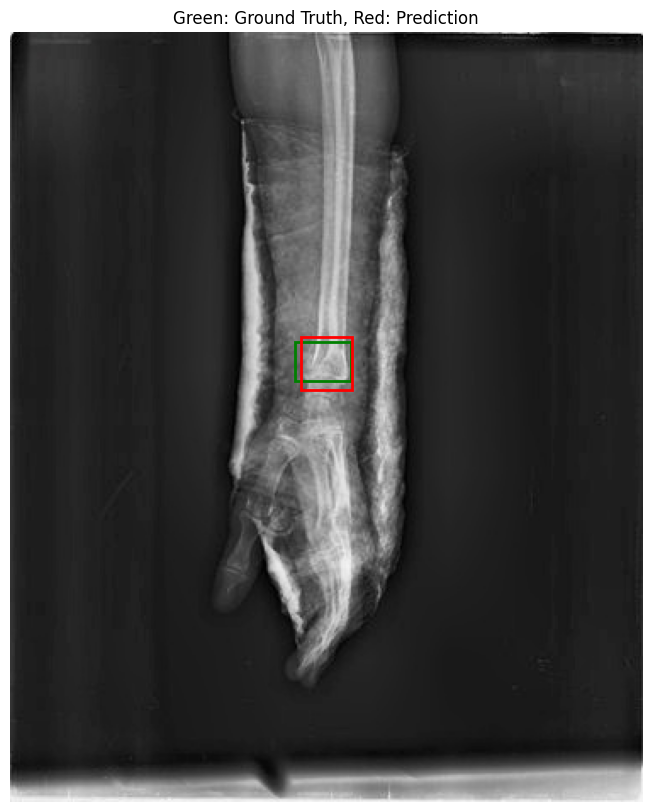

In [16]:
visualize_prediction_vs_ground_truth_from_testset(model_refined_4)

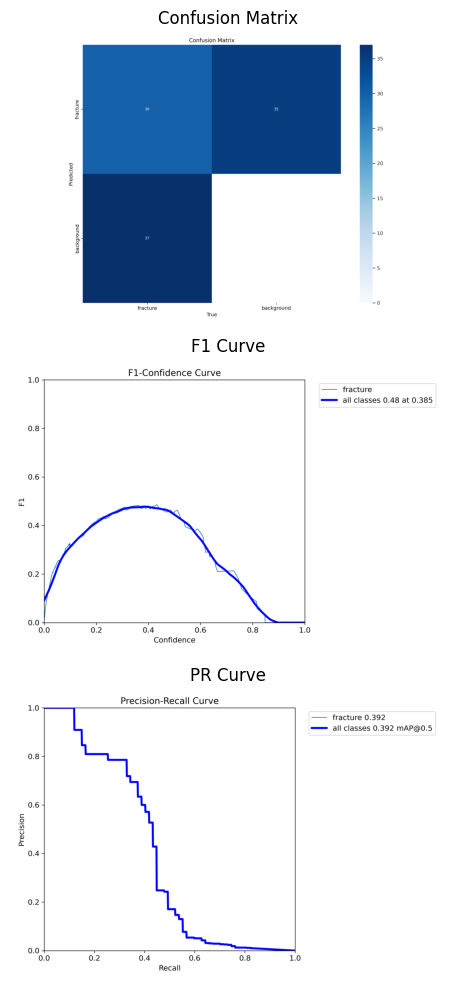

In [17]:
display_eval_curves(refined_3_eval_dir)

## EXPERIMENTS COMPARISION TABLE

In [11]:
models = ['Baseline', 'Experiment 1', 'Experiment 2', 'Experiment 3', 'Experiment 4']
columns = ['Models', 'mAP0.5', 'mAP:0.95', 'Precision', 'Recall', 'F1']
mAP05 = [0.596, 0.434, 0.473, 0.504, 0.513]
mAP095 = [0.325, 0.251, 0.245, 0.223, 0.287]
precision = [0.844, 0.73, 0.75, 0.75, 0.724]
recall = [0.403, 0.164, 0.179, 0.269, 0.313]
f1 = [0.545, 0.268, 0.289, 0.396, 0.438]

width = 15
for col in columns:
    print(f"{col:^{width}}", end=' | ')
print()

for i, model in enumerate(models):

    print(f"{model:^{width}} | {mAP05[i]:^{width}} | {mAP095[i]:^{width}} | {precision[i]:^{width}} | {recall[i]:^{width}} | {f1[i]:^{width}} |")
    

    Models      |     mAP0.5      |    mAP:0.95     |    Precision    |     Recall      |       F1        | 
   Baseline     |      0.596      |      0.325      |      0.844      |      0.403      |      0.545      |
 Experiment 1   |      0.434      |      0.251      |      0.73       |      0.164      |      0.268      |
 Experiment 2   |      0.473      |      0.245      |      0.75       |      0.179      |      0.289      |
 Experiment 3   |      0.504      |      0.223      |      0.75       |      0.269      |      0.396      |
 Experiment 4   |      0.513      |      0.287      |      0.724      |      0.313      |      0.438      |


## SUMMARY OF FINDINGS: 

We started with a baseline model trained using SGD, a learning rate of 1e-3, and 50 epochs. When evaluated on the test set, it delivered the strongest overall results: a mAP@0.5 of 0.596 and a solid F1-score of 0.545. It also had high precision (0.844) and a decent recall (0.403), suggesting the model could reliably detect fractures with good accuracy. 

In Experiment 1, we lowered the learning rate to 1e-4 to encourage slower, more stable learning. However, on the test set, performance took a hit—recall dropped to 0.164 and the F1-score fell to 0.268. It seems the model didn’t have enough capacity to learn effectively under the lower learning rate in the same number of epochs.

For Experiment 2, we went back to the original learning rate but swapped the optimizer to Adam. This helped slightly—recall and F1-score improved compared to Experiment 1, but still didn’t come close to the baseline’s performance.

In Experiment 3, we kept Adam but doubled the training time to 100 epochs. That gave the model more time to learn, which showed in better recall (0.269) and F1-score (0.396) on the test set. It was a clear step in the right direction.

Experiment 4 combined everything: Adam optimizer, 100 epochs, and a lower learning rate. This setup produced the best test performance out of all the experimental models, with a mAP@0.5 of 0.513, recall of 0.313, and the highest F1-score of 0.438. While it still didn’t beat the baseline overall, it showed a better balance between precision and recall, which might be valuable in a real-world medical setting where missing a fracture is more costly than a few false alarms.

These test set results highlight how much of a difference training choices can make—especially when it comes to recall and overall sensitivity. Experiment 4 stands out as a strong alternative if the goal is to improve detection coverage, even if it means giving up a bit of precision.

For submission, we will likely go with the baseline model, which showcases the strongest performance among all model variants.

